In [1]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Create two tensor objects

In [2]:
vocab_size = 5000
embed_dim  = int(vocab_size**(1/2))
print(f'{vocab_size:,} tokens in the vocab, and {embed_dim} embedding dimensions.')

5,000 tokens in the vocab, and 70 embedding dimensions.


In [8]:
E = nn.Embedding(vocab_size, embed_dim) # input [in  x out]
L = nn.Linear(   embed_dim,  vocab_size)# input [out x in]

print(E)
print(L)
print(f'\nEmbedding matrix size: {E.weight.shape}')
print(f'Linear matrix size:    {L.weight.shape}')

Embedding(5000, 70)
Linear(in_features=70, out_features=5000, bias=True)

Embedding matrix size: torch.Size([5000, 70])
Linear matrix size:    torch.Size([5000, 70])


# Explore their attributes

In [9]:
len(dir(E)), len(dir(L))

(129, 123)

In [14]:
dir(E)

['T_destination',
 '__annotations__',
 '__call__',
 '__class__',
 '__constants__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_apply',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_compiled_call_impl',
 '_fill_padding_idx_with_zero',
 '_forward_hooks',
 '_forward_hooks_always_called',
 '_forward_hooks_with_kwargs',
 '_forward_pre_hooks',
 '_forward_pre_hooks_with_kwargs',
 '_get_backward_hooks',
 '_get_backward_pre_hooks',
 '_get_name',
 '_is_full_backward_hook',
 '_load_from_state_dict',
 '_load_state_dict_post_hooks',
 '_load_state_dict_pre_hooks',
 '_maybe_warn_non_full_backward_hook',
 '_modules

In [16]:
# unique attributes of each type
attrE = dir(E)
attrL = dir(L)

print('Attributes in Embedding that are not in Linear:')
for e in attrE:
  if e not in attrL:
    print(' ' + e)

print('\n\nAttributes in Linear that are not in Embedding:')
for l in attrL:
  if l not in attrE:
    print(' ' + l)

Attributes in Embedding that are not in Linear:
 _fill_padding_idx_with_zero
 embedding_dim
 from_pretrained
 max_norm
 norm_type
 num_embeddings
 padding_idx
 scale_grad_by_freq
 sparse


Attributes in Linear that are not in Embedding:
 bias
 in_features
 out_features


# Indexing their vectors

In [17]:
print(E.weight)
print('')
print(L.weight)

Parameter containing:
tensor([[ 0.5172,  0.2149,  1.0597,  ...,  0.3151,  0.5060,  0.8943],
        [ 0.6910, -0.3649, -0.5164,  ...,  0.9576,  0.2273, -1.7711],
        [-0.6178, -0.1079, -0.7490,  ...,  1.7801, -0.8915, -1.4608],
        ...,
        [-1.8892, -1.1695,  0.7214,  ..., -1.0589,  0.6046,  2.2104],
        [ 0.1853,  0.0437,  1.5083,  ..., -0.8732,  0.1817, -1.1813],
        [-0.3637,  0.4298, -0.7417,  ..., -0.4808, -0.1743, -0.0625]],
       requires_grad=True)

Parameter containing:
tensor([[ 0.0479,  0.0608, -0.0701,  ...,  0.0751,  0.0739, -0.0903],
        [-0.0009, -0.0602,  0.0945,  ...,  0.0583, -0.0111, -0.0021],
        [ 0.0233,  0.0874, -0.0388,  ...,  0.0920, -0.1034, -0.0368],
        ...,
        [ 0.0905,  0.1092, -0.0754,  ...,  0.0126,  0.0231, -0.0213],
        [-0.0053,  0.0889,  0.1110,  ..., -0.0326, -0.0252, -0.0454],
        [-0.0816, -0.0013,  0.0058,  ..., -0.0784,  0.0044, -0.0014]],
       requires_grad=True)


In [18]:
token_idx = torch.tensor([14])
E(token_idx)

tensor([[-0.2112, -1.5907,  1.3234, -0.0400,  0.1314, -0.2244,  0.2588,  1.0027,
         -0.7989,  0.7291,  0.3806, -1.0245,  0.7576,  0.0110, -0.5859,  0.3535,
         -1.3010, -1.0038, -0.5338,  0.7841,  0.5586, -0.9726,  0.9619,  0.2263,
          2.2310, -0.6663, -1.0541, -0.8864,  0.1491, -0.3148, -0.4591,  0.2621,
          0.1547,  0.0259, -0.9178, -1.3116,  0.1729, -0.6544,  0.2779, -1.2847,
         -0.5505, -0.3622, -0.5158,  0.4795, -0.9560,  0.1149, -1.4787, -0.8176,
         -1.1974, -0.0220,  1.0182, -1.9715,  0.3420,  1.6051, -0.7195,  0.1184,
         -0.3685, -0.0703,  0.0105,  1.8019,  1.0139,  0.0985, -0.2766, -1.0090,
         -0.8287, -1.4995,  0.3321,  0.3203,  0.9709,  0.9622]],
       grad_fn=<EmbeddingBackward0>)

In [19]:
# L(token_idx)
L.weight[token_idx,:]

tensor([[ 0.0892, -0.0917,  0.1073, -0.0078,  0.0177, -0.1078, -0.0141,  0.0751,
         -0.0249, -0.0513, -0.0476,  0.0505,  0.0908,  0.0608, -0.0709, -0.0661,
          0.0113, -0.0788, -0.0492, -0.0273,  0.1195, -0.0954,  0.0301,  0.0950,
         -0.0731, -0.0605,  0.0916,  0.0508, -0.1038, -0.0674,  0.0885,  0.0465,
         -0.0581,  0.0286, -0.0641, -0.0957, -0.0836,  0.0731, -0.1015, -0.0491,
          0.0962, -0.0494, -0.0370, -0.0385,  0.1127, -0.0830,  0.0569, -0.0399,
          0.0550,  0.1049,  0.1131,  0.0222, -0.0389, -0.0641,  0.0644, -0.1058,
          0.1183, -0.0618,  0.1136,  0.0292, -0.0345,  0.0054, -0.0311,  0.0902,
         -0.0811, -0.0416,  0.0394, -0.0120,  0.0184, -0.1137]],
       grad_fn=<IndexBackward0>)

In [20]:
# explicit one-hot encoding with vector-matrix multiplication
one_hot_vect = torch.zeros(vocab_size, 1)
one_hot_vect[token_idx] = 1

# as vector-matrix multiplication
one_hot_vect.t() @ L.weight

tensor([[ 0.0892, -0.0917,  0.1073, -0.0078,  0.0177, -0.1078, -0.0141,  0.0751,
         -0.0249, -0.0513, -0.0476,  0.0505,  0.0908,  0.0608, -0.0709, -0.0661,
          0.0113, -0.0788, -0.0492, -0.0273,  0.1195, -0.0954,  0.0301,  0.0950,
         -0.0731, -0.0605,  0.0916,  0.0508, -0.1038, -0.0674,  0.0885,  0.0465,
         -0.0581,  0.0286, -0.0641, -0.0957, -0.0836,  0.0731, -0.1015, -0.0491,
          0.0962, -0.0494, -0.0370, -0.0385,  0.1127, -0.0830,  0.0569, -0.0399,
          0.0550,  0.1049,  0.1131,  0.0222, -0.0389, -0.0641,  0.0644, -0.1058,
          0.1183, -0.0618,  0.1136,  0.0292, -0.0345,  0.0054, -0.0311,  0.0902,
         -0.0811, -0.0416,  0.0394, -0.0120,  0.0184, -0.1137]],
       grad_fn=<MmBackward0>)

# Distribution of weights at initialization

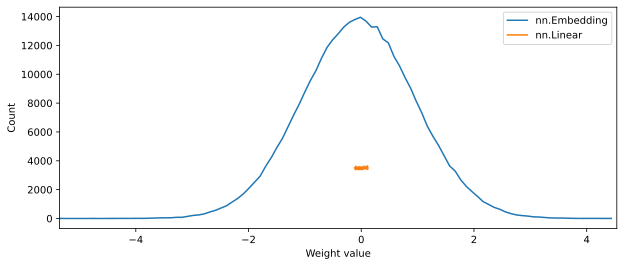

In [21]:
# extract historgrams to get empirical distributions
Ey, Ex = np.histogram(E.weight.flatten().detach(), 100)
Ly, Lx = np.histogram(L.weight.flatten().detach(), 100)

plt.figure(figsize = (10,4))
plt.plot(Ex[:-1], Ey, label = 'nn.Embedding')
plt.plot(Lx[:-1], Ly, label = 'nn.Linear')

plt.gca().set(xlim = [np.min(Ex), np.max(Ex)], xlabel = 'Weight value', ylabel = 'Count')
plt.legend()
plt.show()

In [29]:
print('*** Statistics of nn.Linear weights ***\n')
print(f'Kaiming expected std: { np.sqrt(1/embed_dim)/np.sqrt(3) :.4f}')
print(f'Observed std of L:    {torch.std(L.weight.detach()) :.4f}')

print(f'\nKaiming expected bounds: {np.sqrt(1/embed_dim):.4f}')
print(f'Observed min/max vals: [{torch.min(L.weight):.4f}, {torch.max(L.weight):.4f}]')

*** Statistics of nn.Linear weights ***

Kaiming expected std: 0.0690
Observed std of L:    0.0690

Kaiming expected bounds: 0.1195
Observed min/max vals: [-0.1195, 0.1195]


In [31]:
# repeat the above for Xavier
print('*** Statistics of nn.Embeddings weights ***\n')
print(f'Xavier expected std: {np.sqrt(2/(vocab_size + embed_dim)) :.4f}')
print(f'Observed std of E:   {torch.std(E.weight.detach()) :.4f}')

*** Statistics of nn.Embeddings weights ***

Xavier expected std: 0.0199
Observed std of E:   1.0015


In [32]:
#initialize L to match properties of E
Ln = nn.Linear(embed_dim, vocab_size) # new matrix to avoid overwritting
torch.nn.init.normal_(Ln.weight)

Parameter containing:
tensor([[-1.9076, -0.4008,  0.7211,  ...,  1.8692, -2.7675,  0.1056],
        [-1.3351,  0.3290, -0.9951,  ...,  1.0814,  0.4899, -0.7970],
        [ 0.9493, -1.2600, -0.5150,  ...,  0.7838,  0.3247, -0.6485],
        ...,
        [ 2.3108,  0.0164, -0.1880,  ...,  0.7836, -0.8337,  0.1791],
        [-2.3094,  1.0260, -0.3398,  ...,  1.2963,  0.1470,  0.2438],
        [-1.6686,  0.2490, -0.1161,  ...,  0.4918,  0.8002,  0.8740]],
       requires_grad=True)

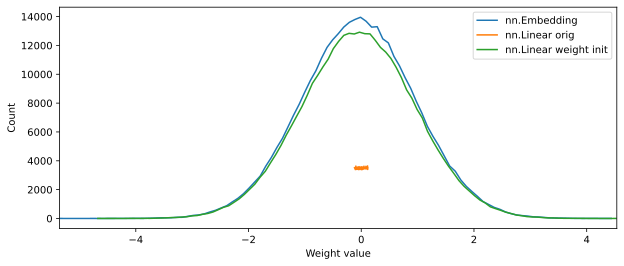

In [33]:
Lny, Lnx = np.histogram(Ln.weight.flatten().detach(), 100)

plt.figure(figsize = (10,4))
plt.plot(Ex[:-1], Ey, label = 'nn.Embedding')
plt.plot(Lx[:-1], Ly, label = 'nn.Linear orig')
plt.plot(Lnx[:-1], Lny, label = 'nn.Linear weight init')

plt.gca().set(xlim = [np.min(Ex), np.max(Ex)], xlabel = 'Weight value', ylabel = 'Count')
plt.legend()
plt.show()

In [34]:
# both created via nn.Parameter
??nn.Embedding
??nn.Linear

In [ ]:
# Conclusions:
#   1) Embeddings weights are initialized as standard normal, not Xavier normal.
#   2) they are "different" for practical reasons but reflect the same thing